Index(['protocol', 'patient_id', 'window_width_seconds', 'stim_channel_name',
       'response_channel_name', 'response_channel_path', 'med_lls',
       'norm_med_lls', 'is_significant', 'snr', 'spearman_p_value',
       'spearman_p_value_fdr_corrected', 'spearman_rho',
       'baseline_percentiles_med'],
      dtype='object')
                      mean_sig  size_sig        se
window_width_seconds                              
0.05                  0.339936      2827  0.008909
0.10                  0.345242      2827  0.008942
0.15                  0.341705      2827  0.008920
0.20                  0.343827      2827  0.008933
0.25                  0.344535      2827  0.008938
0.30                  0.338168      2827  0.008898
0.35                  0.336399      2827  0.008886
0.40                  0.338875      2827  0.008902
0.45                  0.341705      2827  0.008920


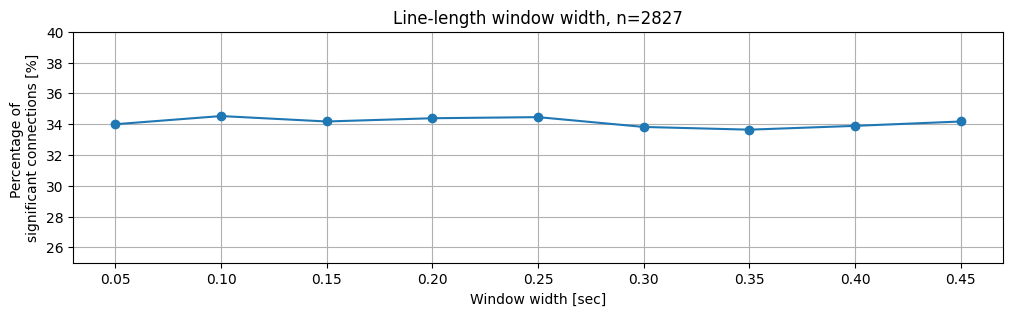

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

allowed_ids = ["EL019", "EL020", "EL021", "EL022", "EL026", "EL027", "EL028", "EL011", "EL013", "EL014", "EL015", "EL016"]

SIGNIFIANCE_LEVEL_SPEAR = 0.995

WINDOW_WIDTH_FILE = "../output/window_analysis/window_width_lf.json"
window_width_df = pd.read_json(WINDOW_WIDTH_FILE)

window_width_df = window_width_df[window_width_df["patient_id"].isin(allowed_ids)]


print(window_width_df.columns)
window_widths = np.array(sorted(window_width_df["window_width_seconds"].unique()))


agg_window_widths = window_width_df.groupby("window_width_seconds").agg(
    mean_sig=("is_significant", "mean"),
    size_sig=("is_significant", "size")
)
agg_window_widths["se"] = (agg_window_widths["mean_sig"] * (1 - agg_window_widths["mean_sig"]) / agg_window_widths["size_sig"]).pow(0.5)
print(agg_window_widths)

plt.figure(figsize=(12, 3))
plt.plot(agg_window_widths.index, agg_window_widths["mean_sig"] * 100, marker='o')
# plt.fill_between(
#     agg_window_widths.index,
#     agg_window_widths["mean_sig"] - 1.96 * agg_window_widths["se"],
#     agg_window_widths["mean_sig"] + 1.96 * agg_window_widths["se"],
#     color='blue',
#     alpha=0.2
# )
plt.ylim(25, 40)
plt.xlabel("Window width [sec]")
plt.ylabel("Percentage of \nsignificant connections [%]")
plt.grid(True)
plt.title(f"Line-length window width, n={len(window_width_df[window_width_df['window_width_seconds'] == window_widths[0]])}")
plt.savefig("../output/figures/sfigure8.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/sfigure8.svg", bbox_inches='tight', dpi=300)
plt.show()


# patient-sepcific
# agg_pat_window_widths = (
#     window_width_df
#     .groupby(["patient_id", "window_width_seconds"])
#     .agg(
#         mean_sig=("is_significant", "mean"),
#         size_sig=("is_significant", "size")
#     )
# )
# plt.figure(figsize=(10, 6))
# for patient_id in allowed_ids:
#     patient_data = agg_pat_window_widths.loc[patient_id]
#     plt.plot(
#         patient_data.index,
#         patient_data["mean_sig"],
#         marker='o',
#         label=patient_id
#     )
# plt.xlabel("Line-length window width [sec]")
# plt.ylabel("Proportion of significant connections")
# plt.title("Line-length window width")
# plt.legend()


# plt.show()